# Table of Contents
1. **Problem Introduction** :

Solar energy plays a major role in Egypt’s current and future energy plans. Aswan, located in Upper Egypt, receives some of the highest solar radiation levels in the world. Because of recent climate changes, solar output has become less predictable, making solar power forecasting a difficult and important challenge.

The goal of this project is to analyze, preprocess, and model solar power output using recent weather measurements collected from Aswan. This includes studying the statistical properties of the dataset, performing feature engineering, reducing dimensionality, and preparing the data for classification-based machine learning models.

This part of the project focuses on cleaning, exploring, and understanding the dataset using Data Science techniques, followed by applying LDA and PCA for dimensionality reduction.

3. **Preprocessing**
   - 3.1 Data Visualization
   - 3.2 Missing Values Treatment
   - 3.3 Binning Process
   - 3.4 Statistical Analysis  
        - Min, Max, Mean  
        - Variance, Standard Deviation  
        - Skewness & Kurtosis  
   - 3.5 Covariance Matrix  
   - 3.6 Correlation Matrix & Heatmap  
   - 3.7 Chi-Square Test  
   - 3.8 Z-test / t-test  
   - 3.9 ANOVA Test  
   - 3.10 Good Charts for Data Interpretation
4. **Feature Reduction & Selection**
   - 4.1 Principal Component Analysis (PCA)
   - 4.2 Linear Discriminant Analysis (LDA)
	 - 4.3 Single Value Decomposition (SVD)
5. **Model Implementations**
   - 5.1 Naive Bayes Classifier
	 - 5.2 Bayesian Beilif Network
   - 5.3 Decision Tree (Entropy & Error-Based)
   - 5.4 LDA Classifier
   - 5.5 PCA Classifier
   - 5.6 K-Nearest Neighbors (KNN) — Multiple Distances
	 - 5.7 Feed-Forward Neural Network (FFNN)
	 - 5.8 Feed-Back Neural Network (RNN)
	 - 5.9 Linear Regession 
	 - 5.10 Logistic Regression
6. **Model Evaluation**
   - 6.1 Confusion Matrix
   - 6.2 Accuracy & Error Rate
   - 6.3 Precision, Recall, F1-Score
   - 6.4 ROC Curve
   - 6.5 FROC Curve
   - 6.6 K-Fold Cross Validation
   - 6.7 Overfitting vs Underfitting Analysis
7. **Results Interpretation**




# 3.1. Loading the Dataset


In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Desktop\Ejust\Training\Ejust\Data Sciecne\Project\AswanData_weatherdata.csv")

print("===== First 10 Rows =====")
display(df.head(10))

print("\nDataset Shape:", df.shape)

print("\n===== DataFrame Info =====")
print(df.info())

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "num_missing": df.isnull().sum(),
    "num_unique": df.nunique()
})

print("\n===== Dataset Overview =====")
display(overview)


===== First 10 Rows =====


,Unnamed: 0,Date,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Pressure,Solar(PV)
0,0,4/1/2022,87.9,31.3,13.4,5.7,29.2,19.010857
1,2,4/3/2022,90.2,34.0,14.2,6.6,29.1,16.885714
2,3,4/4/2022,93.2,31.4,11.8,8.8,29.1,19.627429
3,4,4/5/2022,92.5,24.9,9.4,8.0,29.1,18.929429
4,5,4/6/2022,91.2,18.9,7.8,9.4,29.2,18.934000
5,6,4/7/2022,94.0,26.3,9.4,11.0,29.2,17.435143
6,7,4/8/2022,92.3,24.9,10.0,6.5,29.1,16.717714
7,8,4/9/2022,92.5,30.4,11.9,8.9,29.1,17.146286
8,9,4/10/2022,90.6,32.0,13.3,8.5,29.1,15.938857
9,10,4/11/2022,89.9,30.4,12.3,7.9,29.1,16.939143



Dataset Shape: (398, 8)

===== DataFrame Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      398 non-null    int64  
 1   Date                            398 non-null    object 
 2   AvgTemperture                   398 non-null    float64
 3   AverageDew(point via humidity)  398 non-null    float64
 4   Humidity                        398 non-null    float64
 5   Wind                            398 non-null    float64
 6   Pressure                        398 non-null    float64
 7   Solar(PV)                       398 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 25.0+ KB
None

===== Dataset Overview =====


,dtype,num_missing,num_unique
Unnamed: 0,int64,0,398
Date,object,0,370
AvgTemperture,float64,0,260
AverageDew(point via humidity),float64,0,232
Humidity,float64,0,225
Wind,float64,0,106
Pressure,float64,0,9
Solar(PV),float64,0,368


# 3.2. Missing Values


In [2]:
# Drop unnecessary  column
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Parse Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Check for parsing issues
print("\nAny invalid dates?:", df["Date"].isnull().sum())

# Sort by date (important for weather datasets)
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

print("\nCleaned dataset:")
display(df.head())



Any invalid dates?: 0

Cleaned dataset:


,Date,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Pressure,Solar(PV)
0,2021-04-01,80.0,29.4,16.7,10.9,29.2,31.214857
1,2021-04-02,79.7,31.3,18.1,10.3,29.2,34.046000
2,2021-04-03,77.2,30.4,20.7,10.8,29.2,34.187143
3,2021-04-04,73.1,25.1,17.3,9.0,29.2,31.442286
4,2021-04-05,85.6,26.3,11.8,7.6,29.2,31.606571


# 3.3. Binning Process


In [3]:
# To convert continuous numerical features into discrete categories to reduce noise and improve interpretability.
# Binning AvgTemperature
temp_bins = [0, 70, 85, 110]
temp_labels = ["Low", "Medium", "High"]

df["Temp_Bin"] = pd.cut(df["AvgTemperture"], bins=temp_bins, labels=temp_labels, include_lowest=True)

# Binning Humidity
humidity_bins = [0, 15, 30, 60]
humidity_labels = ["Low", "Medium", "High"]

df["Humidity_Bin"] = pd.cut(df["Humidity"], bins=humidity_bins, labels=humidity_labels, include_lowest=True)

print(df[["AvgTemperture", "Temp_Bin", "Humidity", "Humidity_Bin"]].head())

print(df["Temp_Bin"].value_counts())


   AvgTemperture Temp_Bin  Humidity Humidity_Bin
0           80.0   Medium      16.7       Medium
1           79.7   Medium      18.1       Medium
2           77.2   Medium      20.7       Medium
3           73.1   Medium      17.3       Medium
4           85.6     High      11.8          Low
Temp_Bin
High      199
Medium    103
Low        96
Name: count, dtype: int64


# 3.4. Statical Analysis


In [4]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Create summary table
stats_summary = pd.DataFrame()

stats_summary["min"] = df[numeric_cols].min()
stats_summary["max"] = df[numeric_cols].max()
stats_summary["mean"] = df[numeric_cols].mean()
stats_summary["variance"] = df[numeric_cols].var()
stats_summary["std_dev"] = df[numeric_cols].std()
stats_summary["skewness"] = df[numeric_cols].skew()
stats_summary["kurtosis"] = df[numeric_cols].kurtosis()

display(stats_summary)


,min,max,mean,variance,std_dev,skewness,kurtosis
AvgTemperture,51.100000,102.700000,81.846482,185.316398,13.613097,-0.528708,-0.903930
AverageDew(point via humidity),15.300000,63.900000,36.754020,79.331709,8.906835,0.001333,-0.667801
Humidity,7.400000,47.700000,22.968090,95.191196,9.756598,0.731028,-0.414197
Wind,4.400000,17.100000,10.146734,6.295846,2.509152,0.223224,-0.182979
Pressure,28.900000,29.600000,29.183040,0.019668,0.140241,0.448676,-0.633823
Solar(PV),8.581429,40.038857,24.375258,56.363466,7.507561,0.108514,-1.288024


- 3.5 **Covariance Matrix**
- 3.6 **Correlation Matix**


===== Covariance Matrix =====


,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Pressure,Solar(PV)
AvgTemperture,185.316398,56.149939,-97.565591,4.516890,-1.498763,3.687807
AverageDew(point via humidity),56.149939,79.331709,19.683340,7.761021,-0.363049,-5.092046
Humidity,-97.565591,19.683340,95.191196,2.206180,0.869168,-7.919480
Wind,4.516890,7.761021,2.206180,6.295846,0.007306,3.154827
Pressure,-1.498763,-0.363049,0.869168,0.007306,0.019668,0.045945
Solar(PV),3.687807,-5.092046,-7.919480,3.154827,0.045945,56.363466



===== Correlation Matrix =====


,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Pressure,Solar(PV)
AvgTemperture,1.000000,0.463094,-0.734584,0.132238,-0.785056,0.036084
AverageDew(point via humidity),0.463094,1.000000,0.226505,0.347271,-0.290647,-0.076150
Humidity,-0.734584,0.226505,1.000000,0.090119,0.635229,-0.108118
Wind,0.132238,0.347271,0.090119,1.000000,0.020762,0.167475
Pressure,-0.785056,-0.290647,0.635229,0.020762,1.000000,0.043638
Solar(PV),0.036084,-0.076150,-0.108118,0.167475,0.043638,1.000000


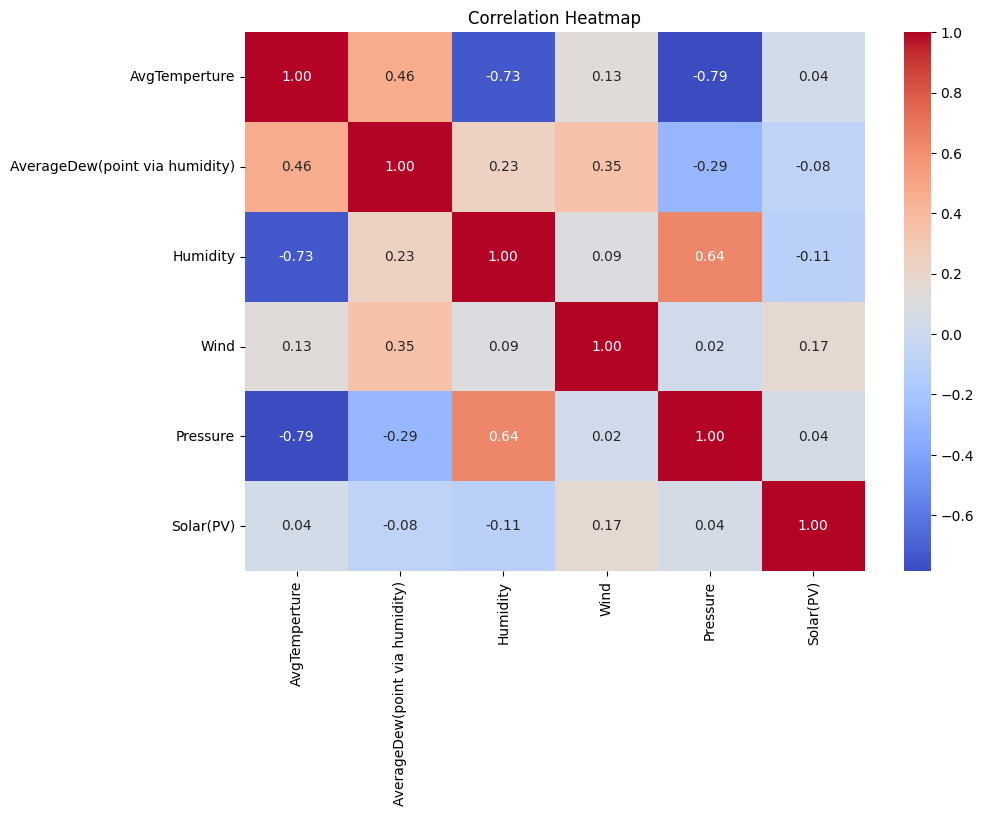

In [5]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Covariance matrix
cov_matrix = df[numeric_cols].cov()
print("===== Covariance Matrix =====")
display(cov_matrix)

# Correlation matrix
corr_matrix = df[numeric_cols].corr()
print("\n===== Correlation Matrix =====")
display(corr_matrix)


plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- 3.7  **Chi-Square**
- 3.8  **T-Test & Z-Test**
- 3.9 **Anova**


In [6]:
# ----------------------------------------
# CHI-SQUARE TEST - To test the association or independence between categorical variables.
# ----------------------------------------
from scipy.stats import chi2_contingency

# Contingency table
chi_table = pd.crosstab(df["Temp_Bin"], df["Humidity_Bin"])

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(chi_table)

print("===== Chi-Square Test =====")
print("Chi-Square Value:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("\nExpected Frequencies:")
display(pd.DataFrame(expected, 
                     index=chi_table.index, 
                     columns=chi_table.columns))

# ----------------------------------------
# T-TEST - To compare means and determine if differences between groups are statistically significant.
# ----------------------------------------
from scipy.stats import ttest_ind

group_low = df[df["Temp_Bin"] == "Low"]["Humidity"]
group_high = df[df["Temp_Bin"] == "High"]["Humidity"]

t_stat, p_val = ttest_ind(group_low.dropna(), group_high.dropna())

print("===== Independent Samples t-test =====")
print("t-statistic:", t_stat)
print("p-value:", p_val)

# ----------------------------------------
# Z-TEST for one sample mean - To compare means and determine if differences between groups are statistically significant.
# ----------------------------------------
from scipy.stats import norm
import numpy as np

sample = df["AvgTemperture"]
population_mean = 80

z_stat = (sample.mean() - population_mean) / (sample.std() / np.sqrt(len(sample)))
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("===== Z-Test =====")
print("z-statistic:", z_stat)
print("p-value:", p_value)

# ----------------------------------------
# ANOVA TEST - To compare the means of three or more groups and check for significant differences.
# ----------------------------------------
from scipy.stats import f_oneway

group_low = df[df["Temp_Bin"] == "Low"]["Humidity"]
group_med = df[df["Temp_Bin"] == "Medium"]["Humidity"]
group_high = df[df["Temp_Bin"] == "High"]["Humidity"]

F, p = f_oneway(group_low.dropna(), group_med.dropna(), group_high.dropna())

print("===== ANOVA =====")
print("F-statistic:", F)
print("p-value:", p)


===== Chi-Square Test =====
Chi-Square Value: 186.22425041746095
p-value: 3.432127429796788e-39
Degrees of Freedom: 4

Expected Frequencies:


Humidity_Bin,Low,Medium,High
Temp_Bin,,,
Low,21.708543,52.824121,21.467337
Medium,23.291457,56.675879,23.032663
High,45.000000,109.500000,44.500000


===== Independent Samples t-test =====
t-statistic: 23.423364703250854
p-value: 4.2102185672278204e-69
===== Z-Test =====
z-statistic: 2.7060124227814604
p-value: 0.006809649852249189
===== ANOVA =====
F-statistic: 221.34143718092184
p-value: 3.3090103074946324e-65


- 3.10 Good Charts

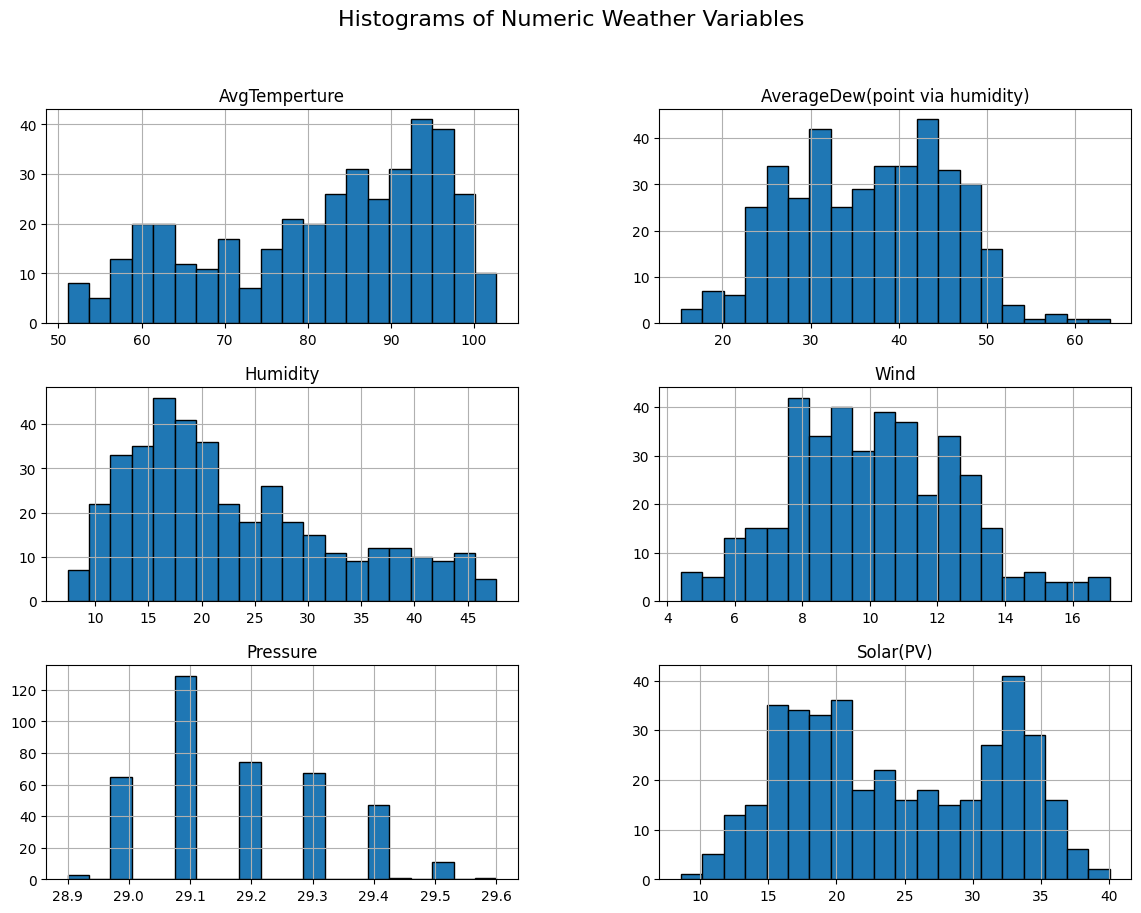

In [7]:
# Histogram for Each Numeric Feature

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

df[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numeric Weather Variables", fontsize=16)
plt.show()


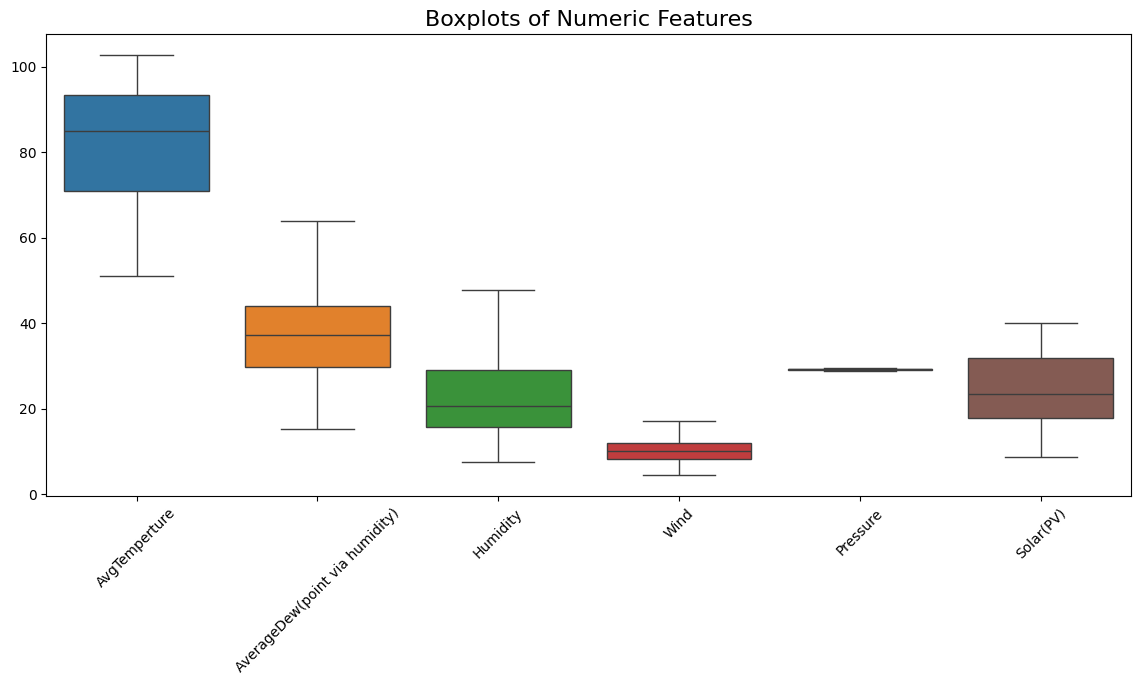

In [8]:
# Boxplots for Outlier Detection

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplots of Numeric Features", fontsize=16)
plt.xticks(rotation=45)
plt.show()


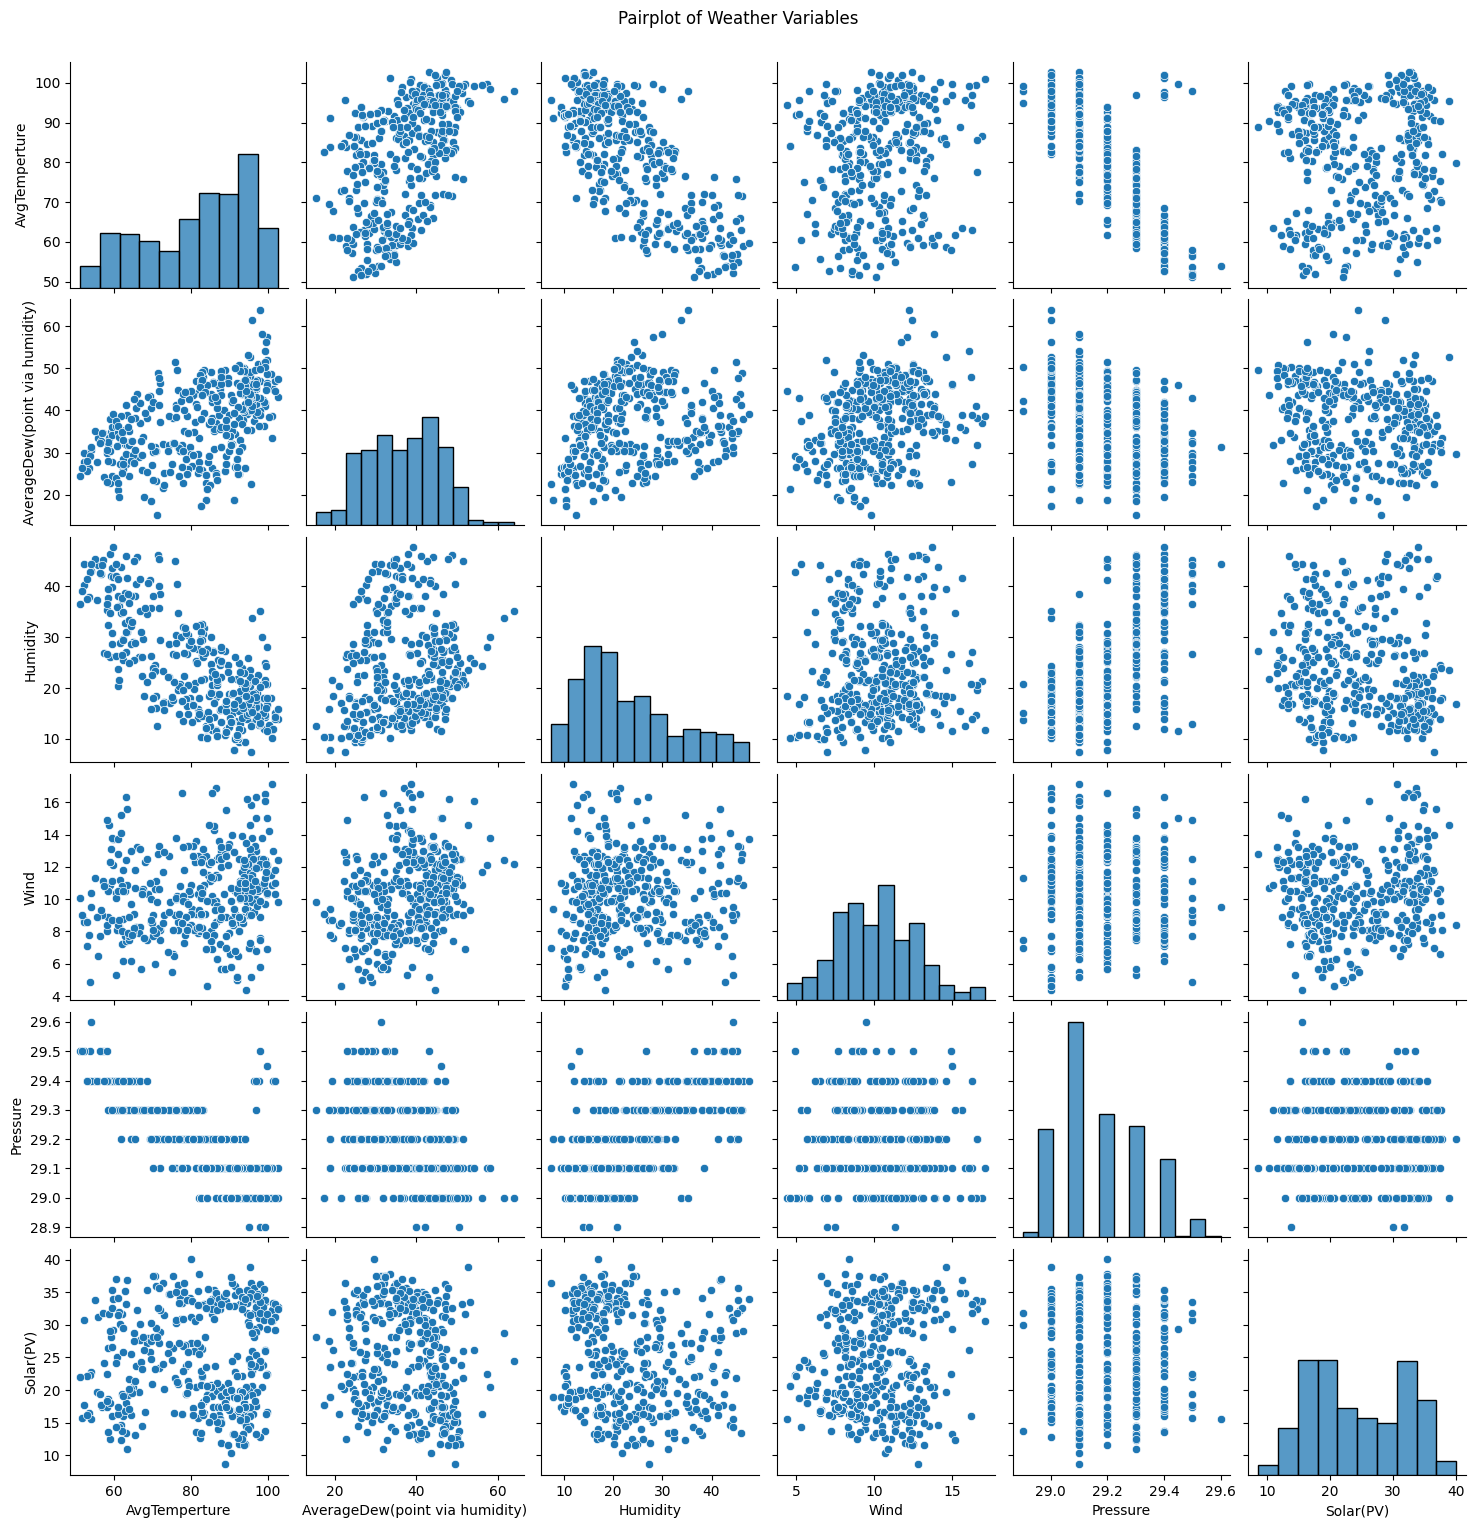

In [9]:
# Shows interactions between variables.
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairplot of Weather Variables", y=1.02)
plt.show()


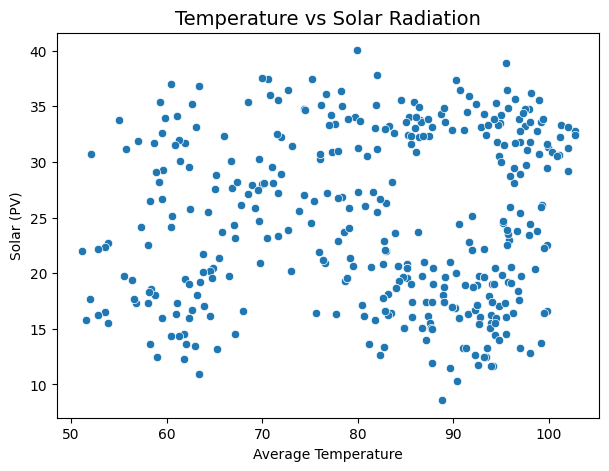

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["AvgTemperture"], y=df["Solar(PV)"])
plt.title("Temperature vs Solar Radiation", fontsize=14)
plt.xlabel("Average Temperature")
plt.ylabel("Solar (PV)")
plt.show()


- 4.1 PCA

In [11]:
# To reduce dimensionality while preserving maximum variance in the data.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Select numeric features only
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# Apply PCA (keep all components first)
pca = PCA()
pca_data = pca.fit_transform(scaled_data)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
print("===== PCA Explained Variance Ratio =====")
for i, var in enumerate(explained_var):
    print(f"PC{i+1}: {var:.4f}")


# Create a DataFrame for the first 2 components
df_pca = pd.DataFrame({
    "PC1": pca_data[:, 0],
    "PC2": pca_data[:, 1],
})

print("\n===== First two PCA components =====")
display(df_pca.head())


===== PCA Explained Variance Ratio =====
PC1: 0.4198
PC2: 0.2450
PC3: 0.1866
PC4: 0.1039
PC5: 0.0416
PC6: 0.0031

===== First two PCA components =====


,PC1,PC2
0,0.020735,-0.622154
1,-0.019736,-0.556899
2,-0.272725,-0.404394
3,-0.488508,-1.412900
4,0.343782,-1.833990


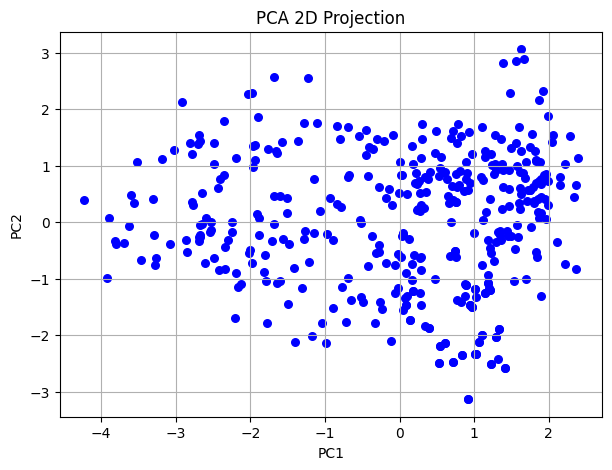

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c='blue', s=30)
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


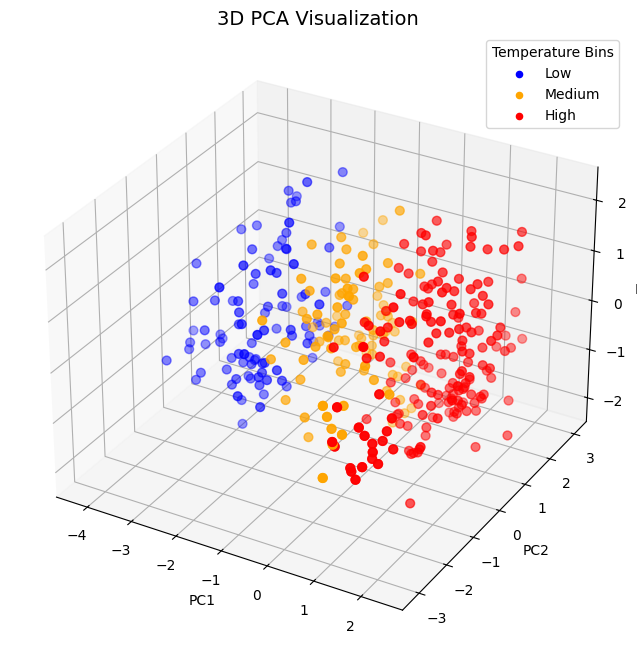

In [13]:
# Create Temperature Bins
temp_bins = [0, 70, 85, 110]
temp_labels = ["Low", "Medium", "High"]
df["Temp_Bin"] = pd.cut(df["AvgTemperture"], bins=temp_bins, labels=temp_labels, include_lowest=True)

# Remove missing
df = df.dropna(subset=["Temp_Bin"])

# Select numeric features
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
X = df[numeric_cols]

# Encode target for color mapping
color_map = {"Low": "blue", "Medium": "orange", "High": "red"}
colors = df["Temp_Bin"].map(color_map)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 3 components
pca = PCA(n_components=3)
pca_3d = pca.fit_transform(X_scaled)

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    pca_3d[:, 0], 
    pca_3d[:, 1], 
    pca_3d[:, 2], 
    c=colors, 
    s=40
)

ax.set_title("3D PCA Visualization", fontsize=14)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

# Legend
for label in color_map:
    ax.scatter([], [], [], color=color_map[label], label=label)
ax.legend(title="Temperature Bins")

plt.show()


- 4.2 LDA

In [14]:
# ----------------------------------------
# STEP 4.2 — LDA Feature Reduction - To reduce dimensionality while maximizing class separability.
# ----------------------------------------

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# LDA can only work when the target is categorical
y = df["Temp_Bin"]  # target
X = df[numeric_cols]  # numeric features

# Encode the target since LDA needs numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Fit LDA
lda = LDA(n_components=2)
lda_data = lda.fit_transform(X, y_encoded)

# Put into DataFrame
df_lda = pd.DataFrame({
    "LD1": lda_data[:, 0],
    "LD2": lda_data[:, 1],
    "Class": y.values
})

print("===== LDA Reduced Components =====")
display(df_lda.head())


===== LDA Reduced Components =====


,LD1,LD2,Class
0,0.370479,1.181783,Medium
1,0.443401,1.450794,Medium
2,1.032288,1.067925,Medium
3,1.738470,2.113057,Medium
4,-0.918717,0.788612,High


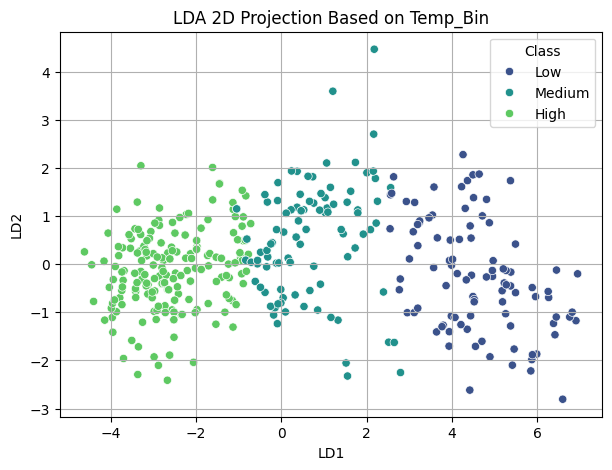

In [15]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(data=df_lda, x="LD1", y="LD2", hue="Class", palette="viridis")
plt.title("LDA 2D Projection Based on Temp_Bin")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(True)
plt.show()


- 4.3 SVD

In [16]:
# To decompose data into components for dimensionality reduction and noise removal. 
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SVD
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape (SVD):", X_svd.shape)


Original shape: (398, 6)
Reduced shape (SVD): (398, 2)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train_svd, X_test_svd, y_train, y_test = train_test_split(
    X_svd, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

svd_model = LogisticRegression(max_iter=1000)
svd_model.fit(X_train_svd, y_train)

svd_accuracy = svd_model.score(X_test_svd, y_test)
print("SVD Model Accuracy:", svd_accuracy)


SVD Model Accuracy: 0.925


In [18]:
print("Explained Variance Ratio:", svd.explained_variance_ratio_)
print("Total Explained Variance:", svd.explained_variance_ratio_.sum())


Explained Variance Ratio: [0.41980661 0.24502214]
Total Explained Variance: 0.6648287522448899


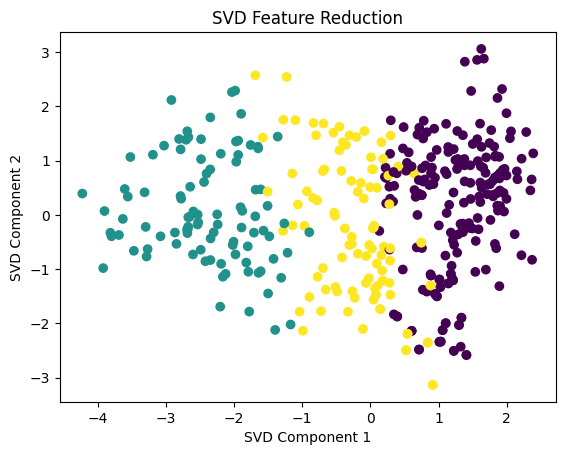

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y_encoded)
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("SVD Feature Reduction")
plt.show()


- 5 Model Implementation

In [20]:
# ----------------------------------------
# Common Setup for All Models
# ----------------------------------------

from sklearn.model_selection import train_test_split

# Select numeric features
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Target variable (from binning step)
y = df["Temp_Bin"]

# Drop rows with NaN in target (if any)
df_clean = df.dropna(subset=["Temp_Bin"])

X = df_clean[numeric_cols]
y = df_clean["Temp_Bin"]

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (318, 6)
Testing set: (80, 6)


- 5.1  Naive Bayes Classifier

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

print("===== Naive Bayes Classification Report =====")
print(classification_report(y_test, y_pred_nb))

print("===== Naive Bayes Confusion Matrix =====")
print(confusion_matrix(y_test, y_pred_nb))



Naive Bayes Accuracy: 0.95
===== Naive Bayes Classification Report =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        40
           1       1.00      0.84      0.91        19
           2       0.87      0.95      0.91        21

    accuracy                           0.95        80
   macro avg       0.95      0.93      0.94        80
weighted avg       0.95      0.95      0.95        80

===== Naive Bayes Confusion Matrix =====
[[40  0  0]
 [ 0 16  3]
 [ 1  0 20]]


- 5.2
  Decision Tree (Entropy)

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)

y_pred_dt_entropy = dt_entropy.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt_entropy))
print("===== Decision Tree (Entropy) Report =====")
print(classification_report(y_test, y_pred_dt_entropy))

print("===== Confusion Matrix =====")
print(confusion_matrix(y_test, y_pred_dt_entropy))


Decision Tree Accuracy: 1.0
===== Decision Tree (Entropy) Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        21

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

===== Confusion Matrix =====
[[40  0  0]
 [ 0 19  0]
 [ 0  0 21]]


- 5.3 LDA Classifier

In [23]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train, y_train)

y_pred_lda = lda_clf.predict(X_test)

print("LDA Classifier Accuracy:", accuracy_score(y_test, y_pred_lda))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lda))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lda))


LDA Classifier Accuracy: 0.9375

Confusion Matrix:
 [[39  0  1]
 [ 0 17  2]
 [ 1  1 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        40
           1       0.94      0.89      0.92        19
           2       0.86      0.90      0.88        21

    accuracy                           0.94        80
   macro avg       0.93      0.92      0.93        80
weighted avg       0.94      0.94      0.94        80



- 5.4 PCA Classifier

In [24]:


from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA with 2 components
pca_model = PCA(n_components=2)
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)

# Classifier
from sklearn.linear_model import LogisticRegression
clf_pca = LogisticRegression(max_iter=1000)
clf_pca.fit(X_train_pca, y_train)

y_pred_pca = clf_pca.predict(X_test_pca)

print("PCA Classifier Accuracy:", accuracy_score(y_test, y_pred_pca))
print("===== PCA Classifier Report =====")
print(classification_report(y_test, y_pred_pca))
print(confusion_matrix(y_test, y_pred_pca))


PCA Classifier Accuracy: 0.9375
===== PCA Classifier Report =====
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        40
           1       0.94      0.89      0.92        19
           2       0.90      0.86      0.88        21

    accuracy                           0.94        80
   macro avg       0.93      0.92      0.92        80
weighted avg       0.94      0.94      0.94        80

[[40  0  0]
 [ 0 17  2]
 [ 2  1 18]]


- 5.5 KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier

distances = ["euclidean", "manhattan", "minkowski"]

for dist in distances:
    print("\n--- KNN with", dist, "distance ---")
    
    knn = KNeighborsClassifier(n_neighbors=5, metric=dist)
    knn.fit(X_train, y_train)
    
    y_pred_knn = knn.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred_knn))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))



--- KNN with euclidean distance ---
Accuracy: 0.9625
Confusion Matrix:
 [[40  0  0]
 [ 0 18  1]
 [ 1  1 19]]

--- KNN with manhattan distance ---
Accuracy: 0.9625
Confusion Matrix:
 [[40  0  0]
 [ 0 18  1]
 [ 2  0 19]]

--- KNN with minkowski distance ---
Accuracy: 0.9625
Confusion Matrix:
 [[40  0  0]
 [ 0 18  1]
 [ 1  1 19]]


- 5.6 Feed-Forward Neural Network (FFNN)


In [26]:
# =====================================
# FEED-FORWARD NEURAL NETWORK (FFNN)
# =====================================

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Define Feed-Forward Neural Network
ffnn = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

# Train model
ffnn.fit(X_train, y_train)

# Predictions
y_pred_ffnn = ffnn.predict(X_test)

# Evaluation
print("===== Feed-Forward Neural Network =====")
print("Accuracy:", accuracy_score(y_test, y_pred_ffnn))
print(classification_report(y_test, y_pred_ffnn))


===== Feed-Forward Neural Network =====
Accuracy: 0.975
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.89      0.94        19
           2       0.91      1.00      0.95        21

    accuracy                           0.97        80
   macro avg       0.97      0.96      0.97        80
weighted avg       0.98      0.97      0.97        80



- 5.7 Feed-Baack Neural Network (RNN)

In [ ]:
# =====================================
# FEED-BACK NEURAL NETWORK (RNN)
# =====================================

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.utils import to_categorical

# Convert labels to categorical
y_cat = to_categorical(y_encoded)

# Reshape features for RNN (samples, timesteps, features)
X_rnn = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Train-test split
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    X_rnn,
    y_cat,
    test_size=0.2,
    random_state=42
)

# Build RNN model
rnn = Sequential()
rnn.add(SimpleRNN(
    32,
    activation="tanh",
    input_shape=(1, X_scaled.shape[1])
))
rnn.add(Dense(y_cat.shape[1], activation="softmax"))

# Compile model
rnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
rnn.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=30,
    batch_size=16,
    verbose=1
)

# Evaluate model
loss, accuracy = rnn.evaluate(X_test_rnn, y_test_rnn, verbose=0)

print("===== Feed-Back Neural Network (RNN) =====")
print("Accuracy:", accuracy)


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resour

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4308 - loss: 1.0649
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6698 - loss: 0.8588 
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7170 - loss: 0.7283 
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7642 - loss: 0.6450 
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7799 - loss: 0.5869 
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7799 - loss: 0.5410
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7987 - loss: 0.5041
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8050 - loss: 0.4732 
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8145 - loss: 0.4468 
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8302 - loss: 0.4225
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8396 - loss: 0.4003
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.861

- 5.8 Linear Regression

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# Target and features
# -------------------------
TARGET = 'Solar(PV)'

X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Drop date (no feature engineering yet)
X = X.drop('Date', axis=1)

# Encode categorical variables if any
X = pd.get_dummies(X, drop_first=True)

# -------------------------
# Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Train model
# -------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Convert to numpy arrays
y_true = y_test.values
y_pred = np.array(y_pred)

# -------------------------
# Evaluation Metrics
# -------------------------

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# R²
r2 = r2_score(y_true, y_pred)

# Willmott’s Index of Agreement
willmott_d = 1 - (
    np.sum((y_pred - y_true) ** 2) /
    np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2)
)

# Nash–Sutcliffe Efficiency (NSE)
nse = 1 - (
    np.sum((y_pred - y_true) ** 2) /
    np.sum((y_true - np.mean(y_true)) ** 2)
)

# Legates–McCabe Index (LMI)
lmi = 1 - (
    np.sum(np.abs(y_pred - y_true)) /
    np.sum(np.abs(y_true - np.mean(y_true)))
)

# -------------------------
# Print Results
# -------------------------
print("Regression Model Evaluation Metrics")
print("----------------------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"Willmott’s Index (d): {willmott_d:.4f}")
print(f"Nash–Sutcliffe Efficiency (NSE): {nse:.4f}")
print(f"Legates–McCabe Index (LMI): {lmi:.4f}")


Regression Model Evaluation Metrics
----------------------------------
MAE  : 6.4649
RMSE : 7.2721
R²   : 0.1012
Willmott’s Index (d): 0.4157
Nash–Sutcliffe Efficiency (NSE): 0.1012
Legates–McCabe Index (LMI): 0.0688


- 5.9 Logistic Regression 

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('Temp_Bin', axis=1)
y = df['Temp_Bin']

X = X.drop('Date', axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        40
         Low       1.00      1.00      1.00        19
      Medium       1.00      1.00      1.00        21

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



- 6 Model Evaluations

In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# Load dataset
df = pd.read_csv(r"C:\Users\HP\Desktop\Ejust\Projects\Data Science\AswanData_weatherdata.csv")

# Drop index-like column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Binning temperature
temp_bins = [0, 70, 85, 110]
temp_labels = ["Low", "Medium", "High"]
df["Temp_Bin"] = pd.cut(df["AvgTemperture"], bins=temp_bins, labels=temp_labels, include_lowest=True)

# Clean
df = df.dropna(subset=["Temp_Bin"])

# Features
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
X = df[numeric_cols]
y = df["Temp_Bin"]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [31]:
def evaluate_all(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Error Rate:", 1 - accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall:", recall_score(y_test, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))


In [32]:
# Naive Bayes Classifier

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

evaluate_all(nb, X_test, y_test, "Naive Bayes")

#Decision Tree (Entropy)

from sklearn.tree import DecisionTreeClassifier

dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)

evaluate_all(dt_entropy, X_test, y_test, "Decision Tree (Entropy)")

# Decision Tree (Error-Based / Gini + Pruning)

dt_error = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
dt_error.fit(X_train, y_train)

evaluate_all(dt_error, X_test, y_test, "Decision Tree (Error-Based)")

# LDA Classifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train, y_train)

evaluate_all(lda_clf, X_test, y_test, "LDA Classifier")

# PCA Classifier (With Logistic Regression)

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Scale first
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# PCA to 2 components
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

# Classifier
pca_clf = LogisticRegression(max_iter=1000)
pca_clf.fit(X_train_pca, y_train)

evaluate_all(pca_clf, X_test_pca, y_test, "PCA Classifier")

from sklearn.neighbors import KNeighborsClassifier

# KNN (Euclidean, Manhattan, Minkowski)

# KNN Euclidean
knn_euclid = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_euclid.fit(X_train, y_train)
evaluate_all(knn_euclid, X_test, y_test, "KNN (Euclidean)")

# KNN Manhattan
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric="manhattan")
knn_manhattan.fit(X_train, y_train)
evaluate_all(knn_manhattan, X_test, y_test, "KNN (Manhattan)")

# KNN Minkowski (default)
knn_minkowski = KNeighborsClassifier(n_neighbors=5, metric="minkowski")
knn_minkowski.fit(X_train, y_train)
evaluate_all(knn_minkowski, X_test, y_test, "KNN (Minkowski)")



===== Naive Bayes =====
Confusion Matrix:
 [[35  0  5]
 [ 0 17  2]
 [ 1  0 20]]
Accuracy: 0.9
Error Rate: 0.09999999999999998
Precision: 0.9180555555555555
Recall: 0.9
F1 Score: 0.9035818713450292

===== Decision Tree (Entropy) =====
Confusion Matrix:
 [[40  0  0]
 [ 0 19  0]
 [ 0  1 20]]
Accuracy: 0.9875
Error Rate: 0.012499999999999956
Precision: 0.9881249999999999
Recall: 0.9875
F1 Score: 0.9875078173858661

===== Decision Tree (Error-Based) =====
Confusion Matrix:
 [[40  0  0]
 [ 0 19  0]
 [ 0  1 20]]
Accuracy: 0.9875
Error Rate: 0.012499999999999956
Precision: 0.9881249999999999
Recall: 0.9875
F1 Score: 0.9875078173858661

===== LDA Classifier =====
Confusion Matrix:
 [[36  0  4]
 [ 0 18  1]
 [ 0  1 20]]
Accuracy: 0.925
Error Rate: 0.07499999999999996
Precision: 0.9349999999999999
Recall: 0.925
F1 Score: 0.9269450800915331

===== PCA Classifier =====
Confusion Matrix:
 [[35  0  5]
 [ 0 17  2]
 [ 3  3 15]]
Accuracy: 0.8375
Error Rate: 0.16249999999999998
Precision: 0.8413785885167

- 6.4 ROC Curve

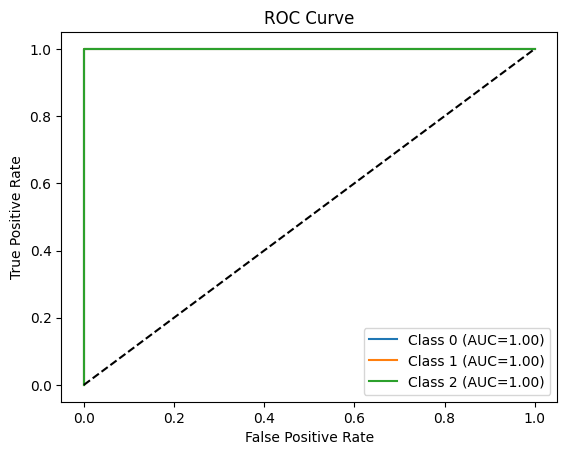

In [33]:
# To analyze classification performance across different decision thresholds.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels for ROC
classes = np.unique(y_encoded)
y_bin = label_binarize(y_encoded, classes=classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, random_state=42, stratify=y_encoded
)

# Simple model (change if needed)
model = OneVsRestClassifier(DecisionTreeClassifier())
model.fit(X_train, y_train)

# Predict probabilities
y_score = model.predict_proba(X_test)

# Plot ROC for each class
for i in range(y_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc_score:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


- 6.5 FROC Curve


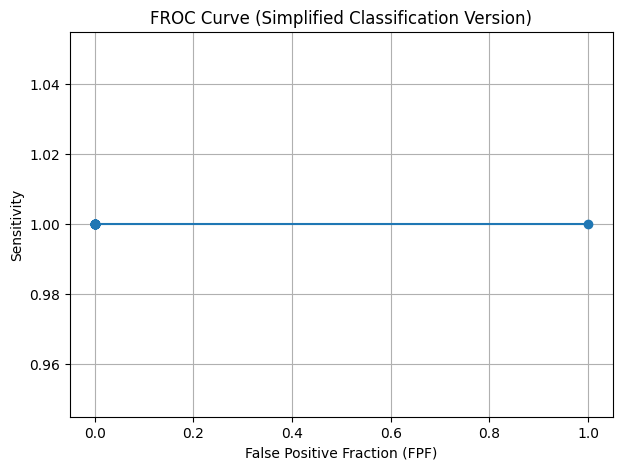

In [34]:
# To evaluate detection performance by balancing sensitivity and false positives.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def compute_froc(y_true, y_score, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 20)

    sensitivities = []
    false_positive_rates = []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn)
        fpf = fp / (fp + tn)   # false positive fraction

        sensitivities.append(sensitivity)
        false_positive_rates.append(fpf)

    return false_positive_rates, sensitivities

# -------------------------------
# Example model (Decision Tree)
# -------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Binary FROC works best → convert High vs not High
y_binary = (y == "High").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# For probability
y_scores = model.predict_proba(X_test)[:, 1]

# Compute FROC
fpf, sens = compute_froc(y_test, y_scores)

# -------------------------------
# Plot FROC curve
# -------------------------------
plt.figure(figsize=(7,5))
plt.plot(fpf, sens, marker='o')

plt.xlabel("False Positive Fraction (FPF)")
plt.ylabel("Sensitivity")
plt.title("FROC Curve (Simplified Classification Version)")
plt.grid(True)
plt.show()


- 6.6 K-Fold Cross Validation 

In [35]:
# To assess model generalization by training and testing on multiple data splits.
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# ----------------------------------------
# Create 10-Fold object
# ----------------------------------------
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# ----------------------------------------
# 1. Naive Bayes
# ----------------------------------------
nb = GaussianNB()
nb_scores = cross_val_score(nb, X, y_encoded, cv=kfold, scoring='accuracy')

# ----------------------------------------
# 2. Decision Tree (Entropy)
# ----------------------------------------
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_scores = cross_val_score(dt, X, y_encoded, cv=kfold, scoring='accuracy')

# ----------------------------------------
# 3. KNN (Euclidean)
# ----------------------------------------
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn_scores = cross_val_score(knn, X, y_encoded, cv=kfold, scoring='accuracy')

# ----------------------------------------
# 4. LDA
# ----------------------------------------
lda = LinearDiscriminantAnalysis()
lda_scores = cross_val_score(lda, X, y_encoded, cv=kfold, scoring='accuracy')

# ----------------------------------------
# 5. PCA Classifier (PCA → Logistic Regression)
# ----------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_clf = LogisticRegression(max_iter=1000)
pca_scores = cross_val_score(pca_clf, X_pca, y_encoded, cv=kfold, scoring='accuracy')

# ----------------------------------------
# PRINT RESULTS
# ----------------------------------------
def print_scores(name, scores):
    print("\n===== {} =====".format(name))
    print("Mean Accuracy:", np.mean(scores))
    print("Std Deviation:", np.std(scores))

print_scores("Naive Bayes", nb_scores)
print_scores("Decision Tree (Entropy)", dt_scores)
print_scores("KNN (Euclidean)", knn_scores)
print_scores("LDA", lda_scores)
print_scores("PCA Classifier", pca_scores)



===== Naive Bayes =====
Mean Accuracy: 0.9548076923076924
Std Deviation: 0.029135655534167304

===== Decision Tree (Entropy) =====
Mean Accuracy: 0.9949999999999999
Std Deviation: 0.010000000000000009

===== KNN (Euclidean) =====
Mean Accuracy: 0.9496794871794872
Std Deviation: 0.03178123415132676

===== LDA =====
Mean Accuracy: 0.9421153846153846
Std Deviation: 0.035641313870813866

===== PCA Classifier =====
Mean Accuracy: 0.9096794871794872
Std Deviation: 0.03197484475192846


- 6.7 Overfitting vs Underfitting


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train a Decision Tree (Entropy)
dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Decision Tree (Entropy)")
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

# Interpretation helper:
if train_acc > 0.95 and (train_acc - test_acc) > 0.10:
    print("\nInterpretation: Model is Overfitting.")
elif train_acc < 0.70 and test_acc < 0.70:
    print("\nInterpretation: Model is Underfitting.")
else:
    print("\nInterpretation: Model is Good (No over/underfitting).")


Decision Tree (Entropy)
Training Accuracy: 1.0
Testing Accuracy: 1.0

Interpretation: Model is Good (No over/underfitting).


In [37]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Initialize and train the Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Make predictions on both training and testing datasets
y_pred_train_nb = nb.predict(X_train)
y_pred_test_nb = nb.predict(X_test)

# Calculate training and testing accuracies
train_acc_nb = accuracy_score(y_train, y_pred_train_nb)
test_acc_nb = accuracy_score(y_test, y_pred_test_nb)

print("Naive Bayes Classifier")
print(f"Training Accuracy: {train_acc_nb:.4f}")
print(f"Testing Accuracy: {test_acc_nb:.4f}")

# Interpretation function (adapted from previous cell)
def interpret_over_underfitting(train_accuracy, test_accuracy):
    if train_accuracy > 0.95 and (train_accuracy - test_accuracy) > 0.10:
        return "Model is Overfitting."
    elif train_accuracy < 0.70 and test_accuracy < 0.70:
        return "Model is Underfitting."
    else:
        return "Model is Good (No over/underfitting)."

# Apply the interpretation
interpretation = interpret_over_underfitting(train_acc_nb, test_acc_nb)
print(f"\nInterpretation: {interpretation}")

Naive Bayes Classifier
Training Accuracy: 0.9676
Testing Accuracy: 0.9500

Interpretation: Model is Good (No over/underfitting).


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the Decision Tree (Entropy) model
dt_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt_entropy.fit(X_train, y_train)

# Make predictions on both training and testing datasets
y_pred_train_dt = dt_entropy.predict(X_train)
y_pred_test_dt = dt_entropy.predict(X_test)

# Calculate training and testing accuracies
train_acc_dt = accuracy_score(y_train, y_pred_train_dt)
test_acc_dt = accuracy_score(y_test, y_pred_test_dt)

print("Decision Tree (Entropy) Classifier")
print(f"Training Accuracy: {train_acc_dt:.4f}")
print(f"Testing Accuracy: {test_acc_dt:.4f}")

# The interpret_over_underfitting function is assumed to be defined from previous execution
# If it's not, it needs to be redefined here.
# For the sake of continuity, I will include its definition again.
def interpret_over_underfitting(train_accuracy, test_accuracy):
    if train_accuracy > 0.95 and (train_accuracy - test_accuracy) > 0.10:
        return "Model is Overfitting."
    elif train_accuracy < 0.70 and test_accuracy < 0.70:
        return "Model is Underfitting."
    else:
        return "Model is Good (No over/underfitting)."

# Apply the interpretation
interpretation_dt = interpret_over_underfitting(train_acc_dt, test_acc_dt)
print(f"\nInterpretation: {interpretation_dt}")

Decision Tree (Entropy) Classifier
Training Accuracy: 1.0000
Testing Accuracy: 1.0000

Interpretation: Model is Good (No over/underfitting).


In [39]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# Initialize and train the LDA Classifier
lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train, y_train)

# Make predictions on both training and testing datasets
y_pred_train_lda = lda_clf.predict(X_train)
y_pred_test_lda = lda_clf.predict(X_test)

# Calculate training and testing accuracies
train_acc_lda = accuracy_score(y_train, y_pred_train_lda)
test_acc_lda = accuracy_score(y_test, y_pred_test_lda)

print("LDA Classifier")
print(f"Training Accuracy: {train_acc_lda:.4f}")
print(f"Testing Accuracy: {test_acc_lda:.4f}")

# The interpret_over_underfitting function is assumed to be defined from previous execution.
# Including its definition again for completeness in this block, if it wasn't explicitly defined globally.
def interpret_over_underfitting(train_accuracy, test_accuracy):
    if train_accuracy > 0.95 and (train_accuracy - test_accuracy) > 0.10:
        return "Model is Overfitting."
    elif train_accuracy < 0.70 and test_accuracy < 0.70:
        return "Model is Underfitting."
    else:
        return "Model is Good (No over/underfitting)."

# Apply the interpretation
interpretation_lda = interpret_over_underfitting(train_acc_lda, test_acc_lda)
print(f"\nInterpretation: {interpretation_lda}")

LDA Classifier
Training Accuracy: 0.9245
Testing Accuracy: 0.9250

Interpretation: Model is Good (No over/underfitting).


In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the KNN model with Minkowski distance
knn_minkowski = KNeighborsClassifier(n_neighbors=5, metric="minkowski")
knn_minkowski.fit(X_train, y_train)

# Make predictions on both training and testing datasets
y_pred_train_knn = knn_minkowski.predict(X_train)
y_pred_test_knn = knn_minkowski.predict(X_test)

# Calculate training and testing accuracies
train_acc_knn = accuracy_score(y_train, y_pred_train_knn)
test_acc_knn = accuracy_score(y_test, y_pred_test_knn)

print("KNN (Minkowski) Classifier")
print(f"Training Accuracy: {train_acc_knn:.4f}")
print(f"Testing Accuracy: {test_acc_knn:.4f}")

# The interpret_over_underfitting function is assumed to be defined from previous execution.
# Including its definition again for completeness in this block.
def interpret_over_underfitting(train_accuracy, test_accuracy):
    if train_accuracy > 0.95 and (train_accuracy - test_accuracy) > 0.10:
        return "Model is Overfitting."
    elif train_accuracy < 0.70 and test_accuracy < 0.70:
        return "Model is Underfitting."
    else:
        return "Model is Good (No over/underfitting)."

# Apply the interpretation
interpretation_knn = interpret_over_underfitting(train_acc_knn, test_acc_knn)
print(f"\nInterpretation: {interpretation_knn}")

KNN (Minkowski) Classifier
Training Accuracy: 0.9712
Testing Accuracy: 0.9833

Interpretation: Model is Good (No over/underfitting).


- 7 Results

In [41]:
import pandas as pd
import numpy as np

# Drop index
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Temperature bins
temp_bins = [0, 70, 85, 110]
temp_labels = ["Low", "Medium", "High"]
df["Temp_Bin"] = pd.cut(df["AvgTemperture"], bins=temp_bins, labels=temp_labels, include_lowest=True)
df = df.dropna(subset=["Temp_Bin"])

# Features & target
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
X = df[numeric_cols]
y = df["Temp_Bin"]

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ---------------------------------------------------------
# DEFINE MODELS
# ---------------------------------------------------------

models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "Decision Tree (Error-Based)": DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42),
    "LDA Classifier": LinearDiscriminantAnalysis(),
    "KNN (Euclidean)": KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
    "KNN (Manhattan)": KNeighborsClassifier(n_neighbors=5, metric="manhattan"),
    "KNN (Minkowski)": KNeighborsClassifier(n_neighbors=5, metric="minkowski")
    
}

# PCA Classifier (uses PCA-transformed data)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

models["PCA Classifier"] = LogisticRegression(max_iter=1000)

# ---------------------------------------------------------
# EVALUATE MODELS & COLLECT METRICS
# ---------------------------------------------------------

results = []

for name, model in models.items():

    # PCA model uses transformed data
    if name == "PCA Classifier":
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    })


# PCA: Principal Component Analysis
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)

# SVD: Singular Value Decomposition
svd = TruncatedSVD(n_components=2)
X_train_svd = svd.fit_transform(X_train_s)
X_test_svd = svd.transform(X_test_s)

# LDA: Linear Discriminant Analysis (Supervised)
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_s, y_train)
X_test_lda = lda.transform(X_test_s)



results = []

for name, model in models.items():
    # Route specific data to specific models
    if name == "PCA Classifier":
        model.fit(X_train_pca, y_train)
        y_pred = model.predict(X_test_pca)
    elif name == "SVD Classifier":
        model.fit(X_train_svd, y_train)
        y_pred = model.predict(X_test_svd)
    elif name == "LDA Classifier":
        model.fit(X_train_lda, y_train)
        y_pred = model.predict(X_test_lda)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
		
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    })

# ---------------------------------------------------------
# OUTPUT THE TABLE
# ---------------------------------------------------------

comparison_df = pd.DataFrame(results)
print(comparison_df)


                         Model  Accuracy  Precision  Recall  F1 Score
0                  Naive Bayes    0.9000   0.918056  0.9000  0.903582
1      Decision Tree (Entropy)    0.9875   0.988125  0.9875  0.987508
2  Decision Tree (Error-Based)    0.9875   0.988125  0.9875  0.987508
3               LDA Classifier    0.9250   0.935000  0.9250  0.926945
4              KNN (Euclidean)    0.9250   0.928333  0.9250  0.925960
5              KNN (Manhattan)    0.9375   0.938884  0.9375  0.937989
6              KNN (Minkowski)    0.9250   0.928333  0.9250  0.925960
7               PCA Classifier    0.8375   0.841379  0.8375  0.838909
